# Card 3 — Análise Exploratória de Dados (EDA)
**Dataset**: TMDB 5000 Movies  
**Foco**: Correlações entre orçamento e popularidade, gêneros/estúdios mais rentáveis, tendências sazonais.

## 1. Imports e Configurações

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from pathlib import Path

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 6)

PROCESSED_FILE = 'tmdb_processed.csv'
print('Ambiente pronto.')

Ambiente pronto.


## 2. Geração do Arquivo Processado (Card 2)
Caso `tmdb_processed.csv` ainda não exista, este bloco faz o pré-processamento e o salva.

In [2]:
def parse_json_column(series, key='name'):
    """Extrai lista de valores de uma coluna JSON-string."""
    def extract(val):
        try:
            return [item[key] for item in json.loads(val)]
        except (json.JSONDecodeError, TypeError, KeyError):
            return []
    return series.apply(extract)


if not Path(PROCESSED_FILE).exists():
    print('Processando dados brutos...')
    movies = pd.read_csv('tmdb_5000_movies.csv')
    credits = pd.read_csv('tmdb_5000_credits.csv')

    # Merge
    df = movies.merge(credits, left_on='id', right_on='movie_id', how='left')
    df.drop(columns=['movie_id', 'title_y'], inplace=True)
    df.rename(columns={'title_x': 'title'}, inplace=True)

    # Parse colunas JSON
    df['genres_list']    = parse_json_column(df['genres'])
    df['companies_list'] = parse_json_column(df['production_companies'])
    df['keywords_list']  = parse_json_column(df['keywords'])

    # Primeiro gênero como categoria principal
    df['main_genre'] = df['genres_list'].apply(lambda x: x[0] if x else 'Unknown')

    # Primeira empresa de produção
    df['main_company'] = df['companies_list'].apply(lambda x: x[0] if x else 'Unknown')

    # Data de lançamento
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
    df['release_year']  = df['release_date'].dt.year
    df['release_month'] = df['release_date'].dt.month

    # Lucro
    df['profit'] = df['revenue'] - df['budget']

    # Remover filmes sem orçamento real e sem receita real
    df = df[(df['budget'] > 0) & (df['revenue'] > 0)].copy()

    # ROI
    df['roi'] = (df['profit'] / df['budget']) * 100

    # Salvar
    df.to_csv(PROCESSED_FILE, index=False)
    print(f'Arquivo salvo: {PROCESSED_FILE} ({len(df)} linhas)')
else:
    print(f'Arquivo já existe: {PROCESSED_FILE}')

Processando dados brutos...


Arquivo salvo: tmdb_processed.csv (3229 linhas)


## 3. Carregamento do Arquivo Processado

In [3]:
df = pd.read_csv(PROCESSED_FILE)

# Recriar listas parseadas (ficam como string após salvar)
import ast
for col in ['genres_list', 'companies_list', 'keywords_list']:
    if col in df.columns:
        df[col] = df[col].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else [])

print('Shape:', df.shape)
df[['title', 'budget', 'revenue', 'profit', 'roi', 'main_genre', 'vote_average', 'popularity']].head(5)

Shape: (3229, 31)


,title,budget,revenue,profit,roi,main_genre,vote_average,popularity
0,Avatar,237000000,2787965087,2550965087,1076.356577,Action,7.2,150.437577
1,Pirates of the Caribbean: At World's End,300000000,961000000,661000000,220.333333,Adventure,6.9,139.082615
2,Spectre,245000000,880674609,635674609,259.459024,Action,6.3,107.376788
3,The Dark Knight Rises,250000000,1084939099,834939099,333.975640,Action,7.6,112.312950
4,John Carter,260000000,284139100,24139100,9.284269,Action,6.1,43.926995


## 4. Estatísticas Descritivas — Notas Médias

In [4]:
stats = df['vote_average'].agg(['mean', 'median', 'std'])
print('=== Estatísticas de vote_average ===')
print(f'  Média:           {stats["mean"]:.4f}')
print(f'  Mediana:         {stats["median"]:.4f}')
print(f'  Desvio Padrão:   {stats["std"]:.4f}')

print()
print('=== Descrição completa do dataset ===')
df[['budget', 'revenue', 'profit', 'roi', 'popularity', 'vote_average', 'vote_count', 'runtime']].describe().round(2)

=== Estatísticas de vote_average ===
  Média:           6.3094
  Mediana:         6.3000
  Desvio Padrão:   0.8739

=== Descrição completa do dataset ===


,budget,revenue,profit,roi,popularity,vote_average,vote_count,runtime
count,3.229000e+03,3.229000e+03,3.229000e+03,3.229000e+03,3229.00,3229.00,3229.00,3229.00
mean,4.065444e+07,1.212430e+08,8.058851e+07,2.953822e+05,29.03,6.31,977.29,110.72
std,4.439674e+07,1.863029e+08,1.581479e+08,1.506101e+07,36.17,0.87,1414.31,20.97
min,1.000000e+00,5.000000e+00,-1.657101e+08,-1.000000e+02,0.02,0.00,0.00,41.00
25%,1.050000e+07,1.700000e+07,2.113940e+05,2.250000e+00,10.45,5.80,178.00,96.00
50%,2.500000e+07,5.518472e+07,2.616557e+07,1.300400e+02,20.41,6.30,471.00,107.00
75%,5.500000e+07,1.462920e+08,9.748982e+07,3.420800e+02,37.34,6.90,1148.00,121.00
max,3.800000e+08,2.787965e+09,2.550965e+09,8.499999e+08,875.58,8.50,13752.00,338.00


## 5. Matriz de Correlação — Pearson e Spearman

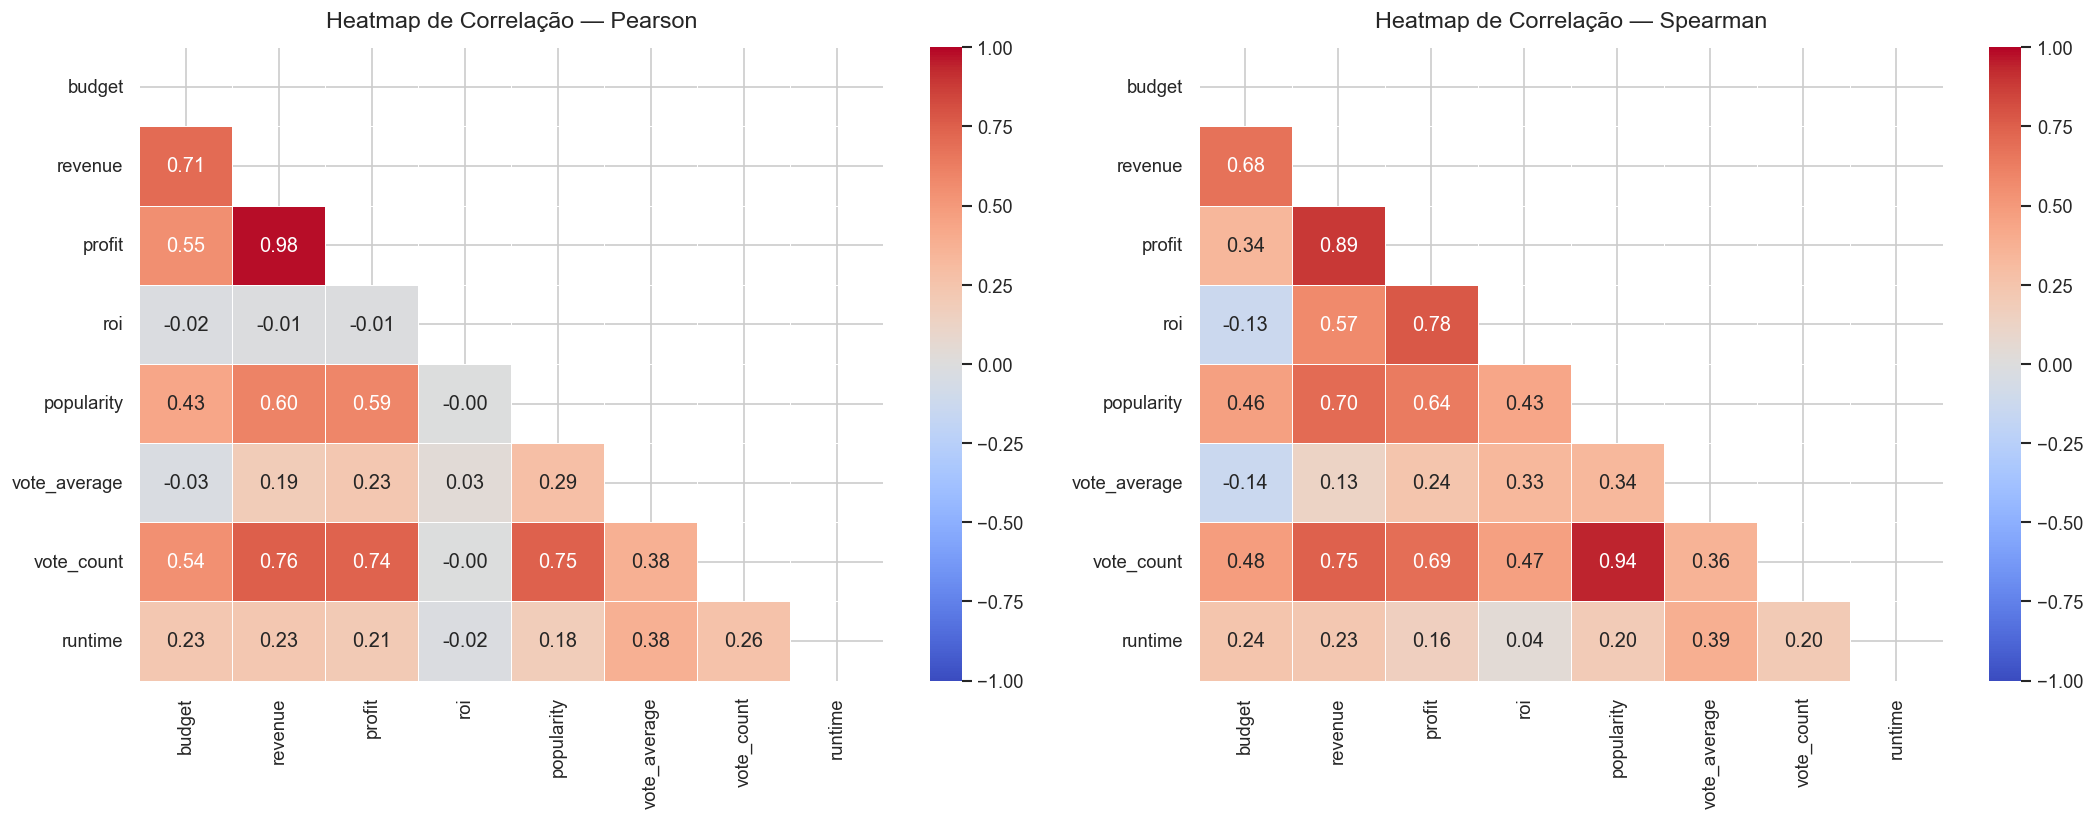

Imagem salva: heatmap_correlacao.png


In [5]:
numeric_cols = ['budget', 'revenue', 'profit', 'roi', 'popularity',
                'vote_average', 'vote_count', 'runtime']

pearson  = df[numeric_cols].corr(method='pearson')
spearman = df[numeric_cols].corr(method='spearman')

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, corr_matrix, title in zip(
    axes,
    [pearson, spearman],
    ['Pearson', 'Spearman']
):
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(
        corr_matrix,
        mask=mask,
        annot=True,
        fmt='.2f',
        cmap='coolwarm',
        vmin=-1, vmax=1,
        linewidths=0.5,
        ax=ax
    )
    ax.set_title(f'Heatmap de Correlação — {title}', fontsize=14, pad=12)

plt.tight_layout()
plt.savefig('heatmap_correlacao.png', bbox_inches='tight')
plt.show()
print('Imagem salva: heatmap_correlacao.png')

In [6]:
# Interpretação textual das principais correlações (Pearson)
print('=== Principais correlações com LUCRO (Pearson) ===')
corr_profit = pearson['profit'].drop('profit').sort_values(key=abs, ascending=False)
for var, val in corr_profit.items():
    direcao = 'positiva' if val > 0 else 'negativa'
    intensidade = 'forte' if abs(val) >= 0.5 else ('moderada' if abs(val) >= 0.3 else 'fraca')
    print(f'  {var:15s}: {val:+.3f}  ({intensidade} {direcao})')

print()
print('=== Principais correlações com POPULARIDADE (Pearson) ===')
corr_pop = pearson['popularity'].drop('popularity').sort_values(key=abs, ascending=False)
for var, val in corr_pop.items():
    direcao = 'positiva' if val > 0 else 'negativa'
    intensidade = 'forte' if abs(val) >= 0.5 else ('moderada' if abs(val) >= 0.3 else 'fraca')
    print(f'  {var:15s}: {val:+.3f}  ({intensidade} {direcao})')

=== Principais correlações com LUCRO (Pearson) ===
  revenue        : +0.980  (forte positiva)
  vote_count     : +0.739  (forte positiva)
  popularity     : +0.588  (forte positiva)
  budget         : +0.550  (forte positiva)
  vote_average   : +0.230  (fraca positiva)
  runtime        : +0.210  (fraca positiva)
  roi            : -0.009  (fraca negativa)

=== Principais correlações com POPULARIDADE (Pearson) ===
  vote_count     : +0.749  (forte positiva)
  revenue        : +0.602  (forte positiva)
  profit         : +0.588  (forte positiva)
  budget         : +0.432  (moderada positiva)
  vote_average   : +0.287  (fraca positiva)
  runtime        : +0.182  (fraca positiva)
  roi            : -0.001  (fraca negativa)


## 6. Gêneros Mais Rentáveis

=== Top 10 gêneros por lucro médio ===
                 qtd_filmes   lucro_medio  lucro_total   roi_medio  nota_media
main_genre                                                                    
Animation                99  2.162605e+08  21409788936  620.670242    6.374747
Family                   38  1.722063e+08   6543840256  271.955661    6.139474
Adventure               288  1.707187e+08  49166978090  471.223211    6.389583
Science Fiction          79  1.461393e+08  11545002700  418.923754    6.339241
Fantasy                  93  1.196426e+08  11126759336  370.346047    6.247312
Action                  588  9.732282e+07  57225815904  187.509053    6.069728
Romance                  70  6.988704e+07   4892093017  343.456709    6.417143
History                  18  6.921722e+07   1245909915  607.323675    6.788889
Mystery                  27  6.598520e+07   1781600420  414.760754    6.325926
Thriller                118  6.087310e+07   7183025782  294.435411    6.170339


C:\Users\Caroline\AppData\Local\Temp\ipykernel_27244\346610827.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Caroline\AppData\Local\Temp\ipykernel_27244\346610827.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


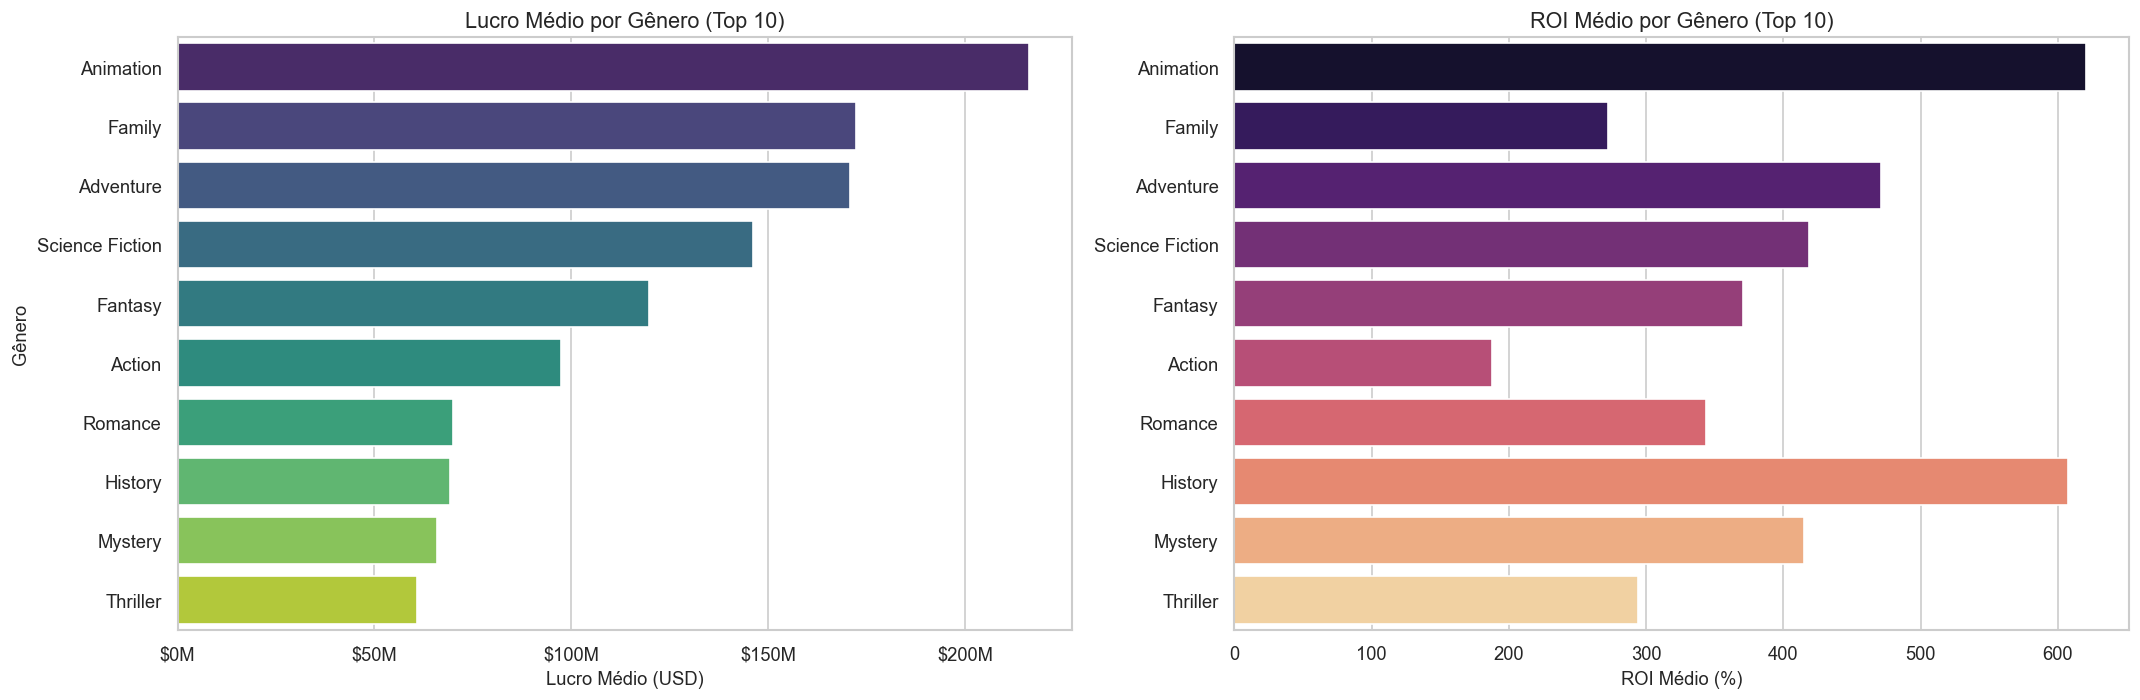

Imagem salva: generos_rentaveis.png


In [7]:
genre_stats = (
    df.groupby('main_genre')
    .agg(
        qtd_filmes=('title', 'count'),
        lucro_medio=('profit', 'mean'),
        lucro_total=('profit', 'sum'),
        roi_medio=('roi', 'mean'),
        nota_media=('vote_average', 'mean'),
    )
    .query('qtd_filmes >= 5')
    .sort_values('lucro_medio', ascending=False)
)

print('=== Top 10 gêneros por lucro médio ===')
print(genre_stats.head(10).to_string())

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top10 = genre_stats.head(10)

sns.barplot(
    data=top10.reset_index(),
    x='lucro_medio', y='main_genre',
    palette='viridis', ax=axes[0]
)
axes[0].set_title('Lucro Médio por Gênero (Top 10)', fontsize=13)
axes[0].set_xlabel('Lucro Médio (USD)', fontsize=11)
axes[0].set_ylabel('Gênero', fontsize=11)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))

sns.barplot(
    data=top10.reset_index(),
    x='roi_medio', y='main_genre',
    palette='magma', ax=axes[1]
)
axes[1].set_title('ROI Médio por Gênero (Top 10)', fontsize=13)
axes[1].set_xlabel('ROI Médio (%)', fontsize=11)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('generos_rentaveis.png', bbox_inches='tight')
plt.show()
print('Imagem salva: generos_rentaveis.png')

## 7. Boxplot — Dispersão de Lucros por Gênero

C:\Users\Caroline\AppData\Local\Temp\ipykernel_27244\3554819670.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


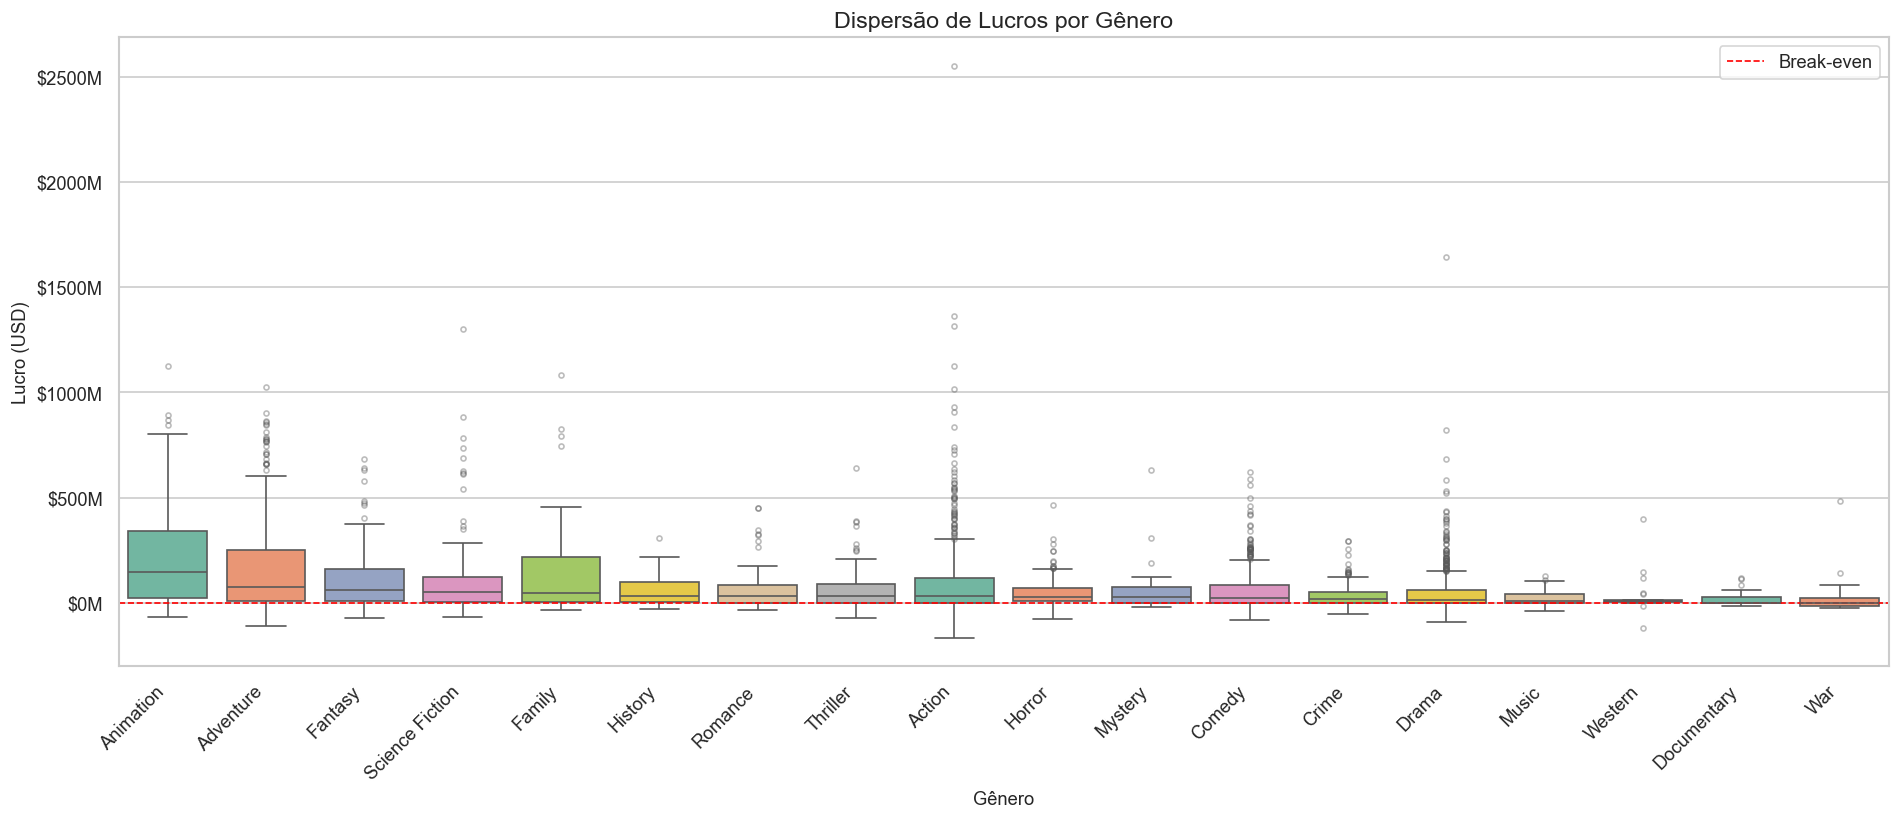

Imagem salva: boxplot_lucro_genero.png


In [8]:
# Selecionar gêneros com ao menos 10 filmes para o boxplot ter sentido
generos_validos = (
    df.groupby('main_genre')
    .filter(lambda g: len(g) >= 10)['main_genre']
    .unique()
)

df_box = df[df['main_genre'].isin(generos_validos)].copy()

# Ordenar pela mediana do lucro
order = (
    df_box.groupby('main_genre')['profit']
    .median()
    .sort_values(ascending=False)
    .index
)

fig, ax = plt.subplots(figsize=(16, 7))
sns.boxplot(
    data=df_box,
    x='main_genre', y='profit',
    order=order,
    palette='Set2',
    flierprops=dict(marker='o', markersize=3, alpha=0.4),
    ax=ax
)
ax.set_title('Dispersão de Lucros por Gênero', fontsize=14)
ax.set_xlabel('Gênero', fontsize=11)
ax.set_ylabel('Lucro (USD)', fontsize=11)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${y/1e6:.0f}M'))
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Break-even')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('boxplot_lucro_genero.png', bbox_inches='tight')
plt.show()
print('Imagem salva: boxplot_lucro_genero.png')

## 8. Estúdios Mais Rentáveis

=== Top 10 estúdios por lucro total ===
                                        qtd_filmes   lucro_medio  lucro_total    roi_medio
main_company                                                                              
Paramount Pictures                             241  1.080669e+08  26044128995   441.450078
Universal Pictures                             228  1.079881e+08  24621286498   390.174352
Walt Disney Pictures                            96  2.006977e+08  19266982158   266.388040
Columbia Pictures                              166  1.068061e+08  17729819796   187.831493
Twentieth Century Fox Film Corporation         159  1.023076e+08  16266904544   377.852965
New Line Cinema                                135  6.492931e+07   8765457493   853.824682
DreamWorks SKG                                  54  1.332546e+08   7195749688   231.597223
Village Roadshow Pictures                       64  1.086133e+08   6951254238   147.552999
Lucasfilm                                       14

C:\Users\Caroline\AppData\Local\Temp\ipykernel_27244\4092967894.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\Caroline\AppData\Local\Temp\ipykernel_27244\4092967894.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


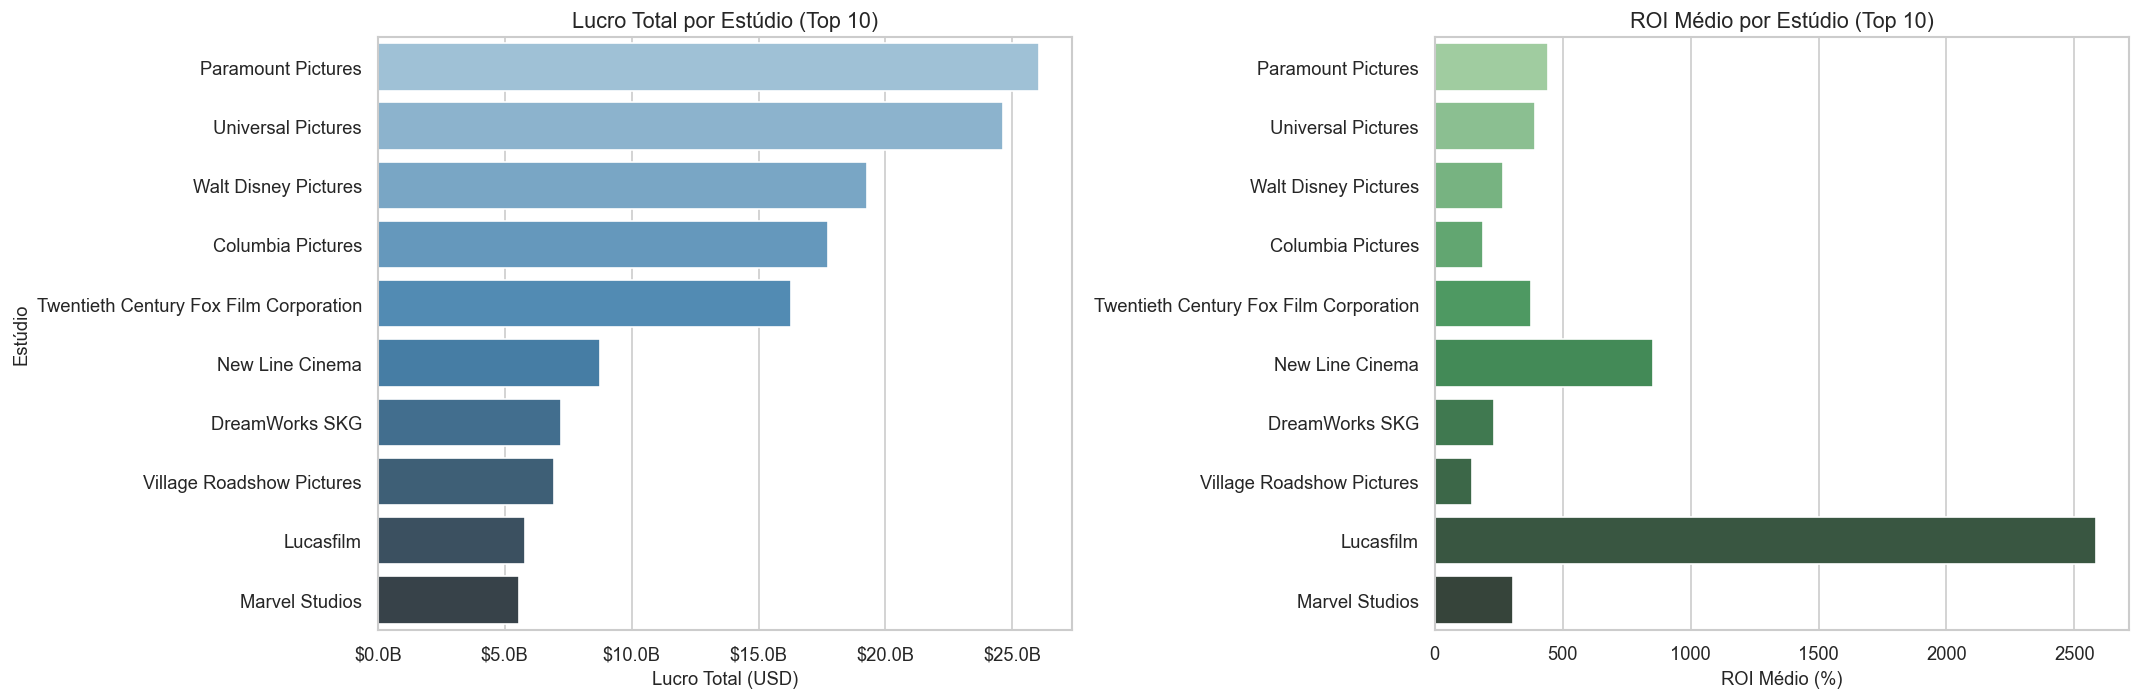

Imagem salva: estudios_rentaveis.png


In [9]:
studio_stats = (
    df.groupby('main_company')
    .agg(
        qtd_filmes=('title', 'count'),
        lucro_medio=('profit', 'mean'),
        lucro_total=('profit', 'sum'),
        roi_medio=('roi', 'mean'),
    )
    .query('qtd_filmes >= 5')
    .sort_values('lucro_total', ascending=False)
)

print('=== Top 10 estúdios por lucro total ===')
print(studio_stats.head(10).to_string())

top10_studios = studio_stats.head(10).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=top10_studios,
    x='lucro_total', y='main_company',
    palette='Blues_d', ax=axes[0]
)
axes[0].set_title('Lucro Total por Estúdio (Top 10)', fontsize=13)
axes[0].set_xlabel('Lucro Total (USD)', fontsize=11)
axes[0].set_ylabel('Estúdio', fontsize=11)
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1e9:.1f}B'))

sns.barplot(
    data=top10_studios,
    x='roi_medio', y='main_company',
    palette='Greens_d', ax=axes[1]
)
axes[1].set_title('ROI Médio por Estúdio (Top 10)', fontsize=13)
axes[1].set_xlabel('ROI Médio (%)', fontsize=11)
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('estudios_rentaveis.png', bbox_inches='tight')
plt.show()
print('Imagem salva: estudios_rentaveis.png')

## 9. Tendências Sazonais de Lançamento

C:\Users\Caroline\AppData\Local\Temp\ipykernel_27244\3498222755.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=seasonal, x='mes', y=col, palette='rocket', ax=ax)
C:\Users\Caroline\AppData\Local\Temp\ipykernel_27244\3498222755.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=seasonal, x='mes', y=col, palette='rocket', ax=ax)
C:\Users\Caroline\AppData\Local\Temp\ipykernel_27244\3498222755.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=seasonal, x='mes', y=col, palette='rocket', ax=ax)


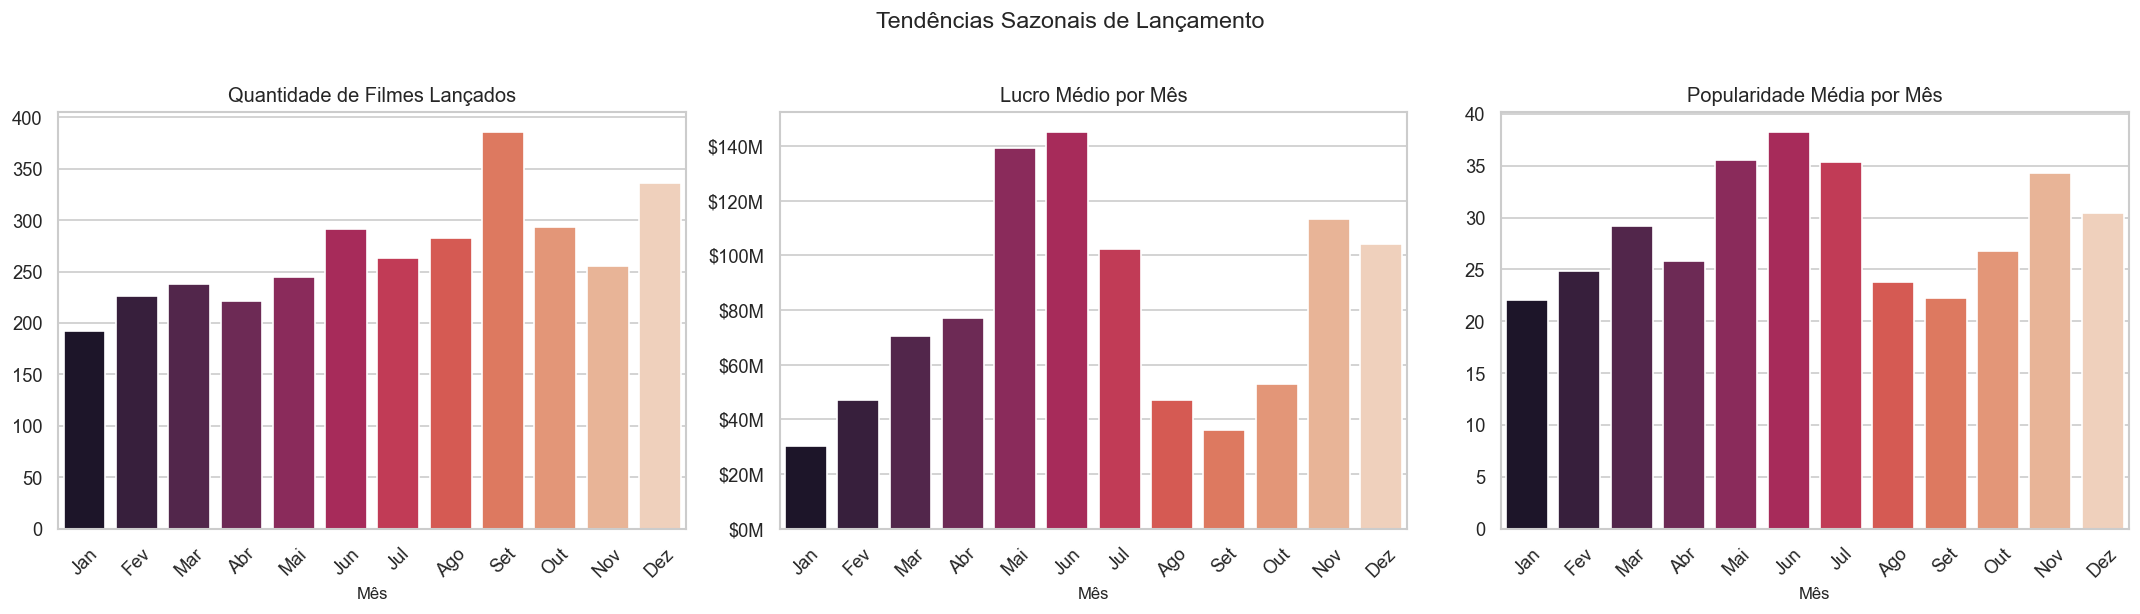

Imagem salva: tendencias_sazonais.png


In [10]:
month_names = {
    1:'Jan', 2:'Fev', 3:'Mar', 4:'Abr', 5:'Mai', 6:'Jun',
    7:'Jul', 8:'Ago', 9:'Set', 10:'Out', 11:'Nov', 12:'Dez'
}

seasonal = (
    df.groupby('release_month')
    .agg(
        qtd_filmes=('title', 'count'),
        lucro_medio=('profit', 'mean'),
        popularidade_media=('popularity', 'mean'),
    )
    .reset_index()
)
seasonal['mes'] = seasonal['release_month'].map(month_names)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, titulo, fmt in zip(
    axes,
    ['qtd_filmes', 'lucro_medio', 'popularidade_media'],
    ['Quantidade de Filmes Lançados', 'Lucro Médio por Mês', 'Popularidade Média por Mês'],
    [None, 'usd', None]
):
    sns.barplot(data=seasonal, x='mes', y=col, palette='rocket', ax=ax)
    ax.set_title(titulo, fontsize=12)
    ax.set_xlabel('Mês', fontsize=10)
    ax.set_ylabel('')
    if fmt == 'usd':
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${y/1e6:.0f}M'))
    plt.setp(ax.get_xticklabels(), rotation=45)

plt.suptitle('Tendências Sazonais de Lançamento', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('tendencias_sazonais.png', bbox_inches='tight')
plt.show()
print('Imagem salva: tendencias_sazonais.png')

## 10. Resumo dos Achados

In [11]:
top_genero_lucro  = genre_stats.index[0]
top_genero_roi    = genre_stats['roi_medio'].idxmax()
top_estudio       = studio_stats.index[0]
melhor_mes_lucro  = seasonal.loc[seasonal['lucro_medio'].idxmax(), 'mes']
melhor_mes_qtd    = seasonal.loc[seasonal['qtd_filmes'].idxmax(), 'mes']

corr_budget_pop   = pearson.loc['budget', 'popularity']
corr_budget_profit = pearson.loc['budget', 'profit']

print('=' * 55)
print('           RESUMO DOS ACHADOS — CARD 3 EDA')
print('=' * 55)
print(f'  vote_average  → média: {df["vote_average"].mean():.2f}'
      f' | mediana: {df["vote_average"].median():.2f}'
      f' | std: {df["vote_average"].std():.2f}')
print()
print(f'  Correlação budget × popularity : {corr_budget_pop:+.3f}')
print(f'  Correlação budget × profit     : {corr_budget_profit:+.3f}')
print()
print(f'  Gênero com maior lucro médio   : {top_genero_lucro}')
print(f'  Gênero com maior ROI médio     : {top_genero_roi}')
print(f'  Estúdio com maior lucro total  : {top_estudio}')
print()
print(f'  Mês com maior lucro médio      : {melhor_mes_lucro}')
print(f'  Mês com mais lançamentos       : {melhor_mes_qtd}')
print('=' * 55)

           RESUMO DOS ACHADOS — CARD 3 EDA
  vote_average  → média: 6.31 | mediana: 6.30 | std: 0.87

  Correlação budget × popularity : +0.432
  Correlação budget × profit     : +0.550

  Gênero com maior lucro médio   : Animation
  Gênero com maior ROI médio     : Drama
  Estúdio com maior lucro total  : Paramount Pictures

  Mês com maior lucro médio      : Jun
  Mês com mais lançamentos       : Set
